Create paths and retrieve data

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm


In [2]:
factors = pd.read_excel("project Factors_2026.xlsx")
stocks = pd.read_excel("project Stocks_2026.xlsx")
funds = pd.read_excel("project Funds_2026.xlsx")



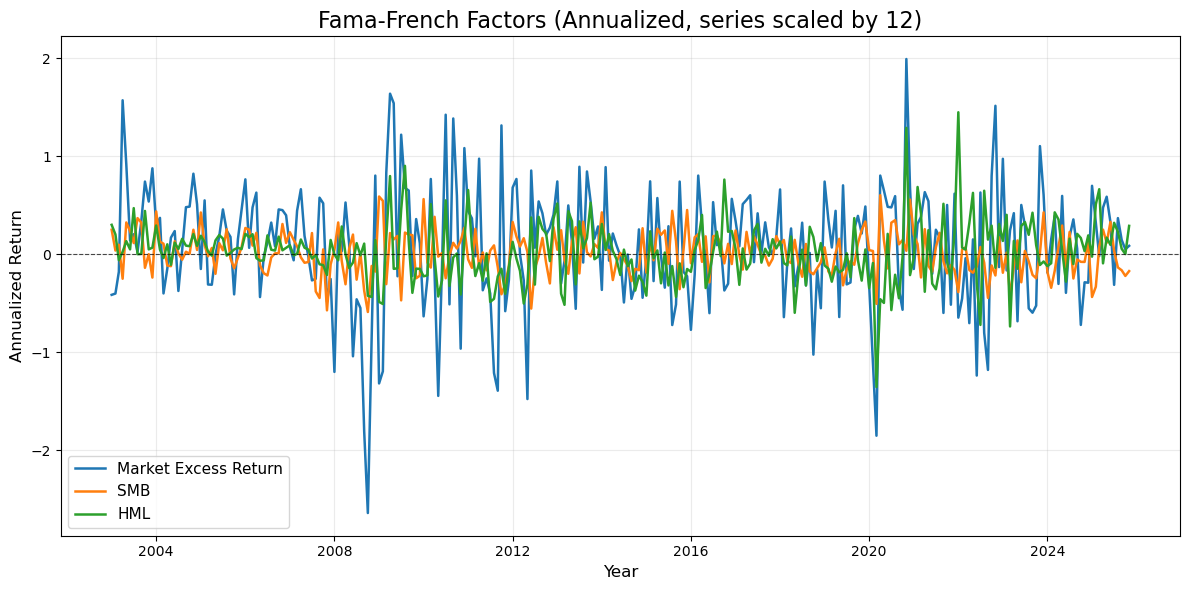

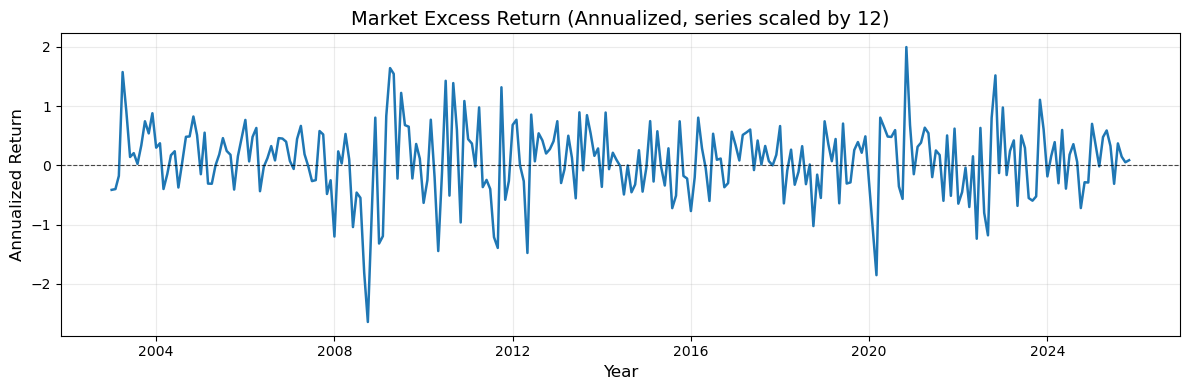

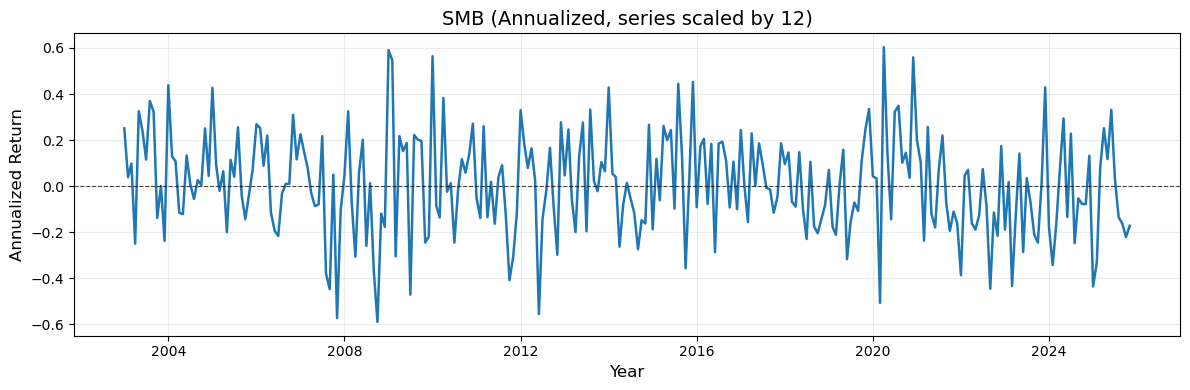

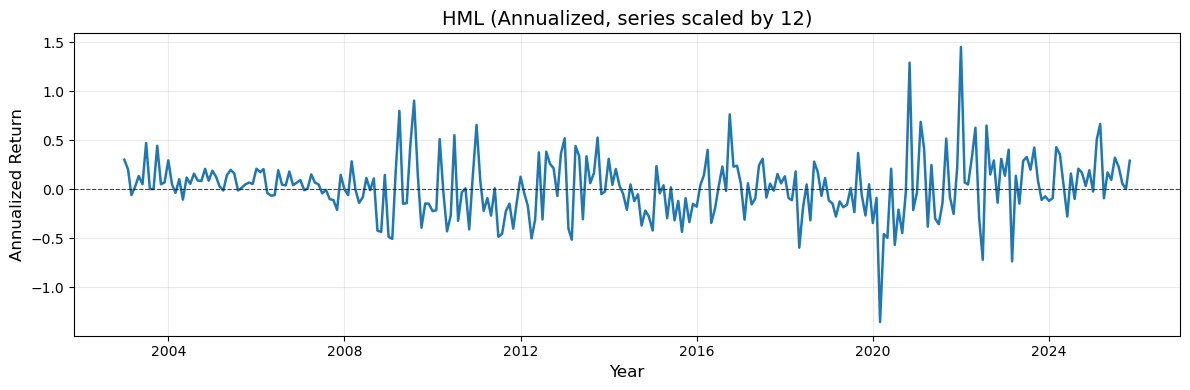

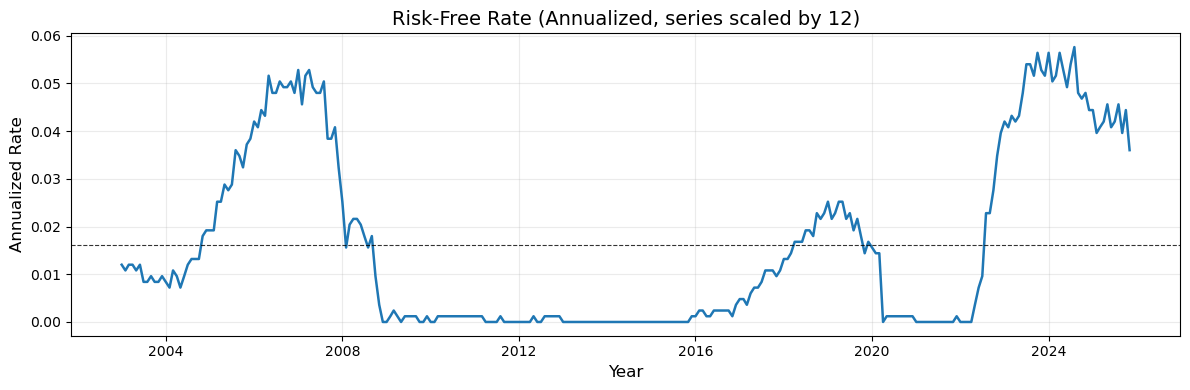

,"Mean (Annual, decimal)","Std Dev (Annual, decimal)"
Rm - Rf,0.0841,0.1790
SMB,0.0087,0.0631
HML,0.0218,0.0887


,"rf_mean (Annual, decimal)"
0,0.0161


,Market Excess,SMB,HML,Risk-Free
Market Excess,0.0320,0.0007,0.0052,0.0000
SMB,0.0007,0.0040,-0.0005,-0.0000
HML,0.0052,-0.0005,0.0079,0.0001
Risk-Free,0.0000,-0.0000,0.0001,0.0000


,Market Excess,SMB,HML,Risk-Free
Market Excess,1.0000,0.0576,0.3302,0.0100
SMB,0.0576,1.0000,-0.0812,-0.1392
HML,0.3302,-0.0812,1.0000,0.1140
Risk-Free,0.0100,-0.1392,0.1140,1.0000


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Copy data ---
factors_q1 = factors.copy()
stocks_q1  = stocks.copy()

# --- Ensure numeric ---
factor_cols = ['rm_rf', 'smb_vw', 'hml_vw', 'rf']
f = factors_q1[factor_cols].apply(pd.to_numeric, errors='coerce')

# --- Build date index (year/month if available) ---
cols_lower = {c.lower(): c for c in factors_q1.columns}
if 'year' in cols_lower and 'month' in cols_lower:
    x_dates = pd.to_datetime(
        dict(
            year=factors_q1[cols_lower['year']].astype(int),
            month=factors_q1[cols_lower['month']].astype(int),
            day=1
        )
    )
else:
    # fallback: use index if already datetime-like
    x_dates = factors_q1.index

# =========================
# 1) PLOTS (Annualized units)
# =========================
# If you want plots in "annual units" per assignment instruction:
f_plot = f * 12

plt.figure(figsize=(12,6))
plt.plot(x_dates, f_plot['rm_rf'], label='Market Excess Return', linewidth=1.8)
plt.plot(x_dates, f_plot['smb_vw'], label='SMB', linewidth=1.8)
plt.plot(x_dates, f_plot['hml_vw'], label='HML', linewidth=1.8)
plt.axhline(0, color='black', linewidth=0.8, alpha=0.7, linestyle='--')
plt.title("Fama-French Factors (Annualized, series scaled by 12)", fontsize=16)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Annualized Return", fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

for col, ttl in [('rm_rf','Market Excess Return'),
                 ('smb_vw','SMB'),
                 ('hml_vw','HML')]:
    plt.figure(figsize=(12,4))
    plt.plot(x_dates, f_plot[col], linewidth=1.8)
    plt.axhline(0, color='black', linewidth=0.8, alpha=0.7, linestyle='--')
    plt.title(f"{ttl} (Annualized, series scaled by 12)", fontsize=14)
    plt.xlabel("Year", fontsize=12)
    plt.ylabel("Annualized Return", fontsize=12)
    plt.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()

# Risk-free plot (annualized series)
rf_plot = f_plot['rf']
rf_mean_annual = f['rf'].mean() * 12  # annualized mean (correct)

plt.figure(figsize=(12,4))
plt.plot(x_dates, rf_plot, linewidth=1.8)
plt.axhline(rf_mean_annual, color='black', linewidth=0.8, alpha=0.8, linestyle='--')
plt.title("Risk-Free Rate (Annualized, series scaled by 12)", fontsize=14)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Annualized Rate", fontsize=12)
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

# =========================
# 2) SUMMARY STATS (Correct annualization)
# =========================
# Correct annualization of moments:
# mean_ann = 12 * mean_month
# std_ann  = sqrt(12) * std_month
# cov_ann  = 12 * cov_month

mean_ann = f[['rm_rf','smb_vw','hml_vw']].mean() * 12
std_ann  = f[['rm_rf','smb_vw','hml_vw']].std() * np.sqrt(12)

factor_stats = pd.DataFrame({
    "Mean (Annual, decimal)": mean_ann,
    "Std Dev (Annual, decimal)": std_ann
})
factor_stats.index = ["Rm - Rf", "SMB", "HML"]
display(factor_stats.round(4))

display(pd.DataFrame({"rf_mean (Annual, decimal)": [rf_mean_annual]}).round(4))

# Annualized covariance matrix (correct)
cov_ann = f[['rm_rf','smb_vw','hml_vw','rf']].cov() * 12
cov_ann.index = ['Market Excess', 'SMB', 'HML', 'Risk-Free']
cov_ann.columns = ['Market Excess', 'SMB', 'HML', 'Risk-Free']

display(cov_ann.round(4))

# Optional: correlation matrix (often more interpretable)
corr = f[['rm_rf','smb_vw','hml_vw','rf']].corr()
corr.index = ['Market Excess', 'SMB', 'HML', 'Risk-Free']
corr.columns = ['Market Excess', 'SMB', 'HML', 'Risk-Free']
display(corr.round(4))

1.)

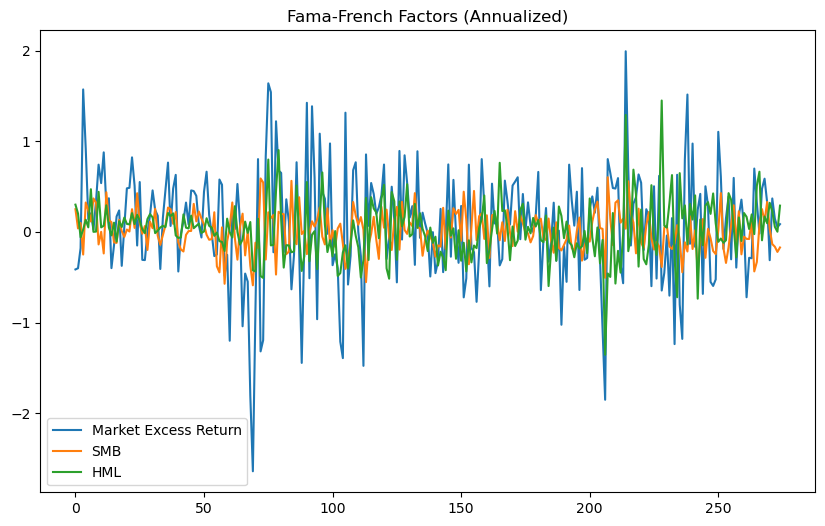

Average factor returns:
rm_rf     0.084113
smb_vw    0.008662
hml_vw    0.021844
dtype: float64

Variance-Covariance matrix:
           rm_rf    smb_vw    hml_vw
rm_rf   0.384355  0.007809  0.062876
smb_vw  0.007809  0.047823 -0.005452
hml_vw  0.062876 -0.005452  0.094322

Average Risk Free Rate:
0.016088727272727275


In [ ]:
factors[['rm_rf','smb_vw','hml_vw','rf']] *= 12
stocks.iloc[:,3:] *= 12   


plt.figure(figsize=(10,6))
plt.plot(factors['rm_rf'], label='Market Excess Return')
plt.plot(factors['smb_vw'], label='SMB')
plt.plot(factors['hml_vw'], label='HML')
plt.legend()
plt.title("Fama-French Factors (Annualized)")
plt.show()

print("Average factor returns:")
print(factors[['rm_rf','smb_vw','hml_vw']].mean())

print("\nVariance-Covariance matrix:")
print(factors[['rm_rf','smb_vw','hml_vw']].cov())

print("\nAverage Risk Free Rate:")
print(factors['rf'].mean())


2.)

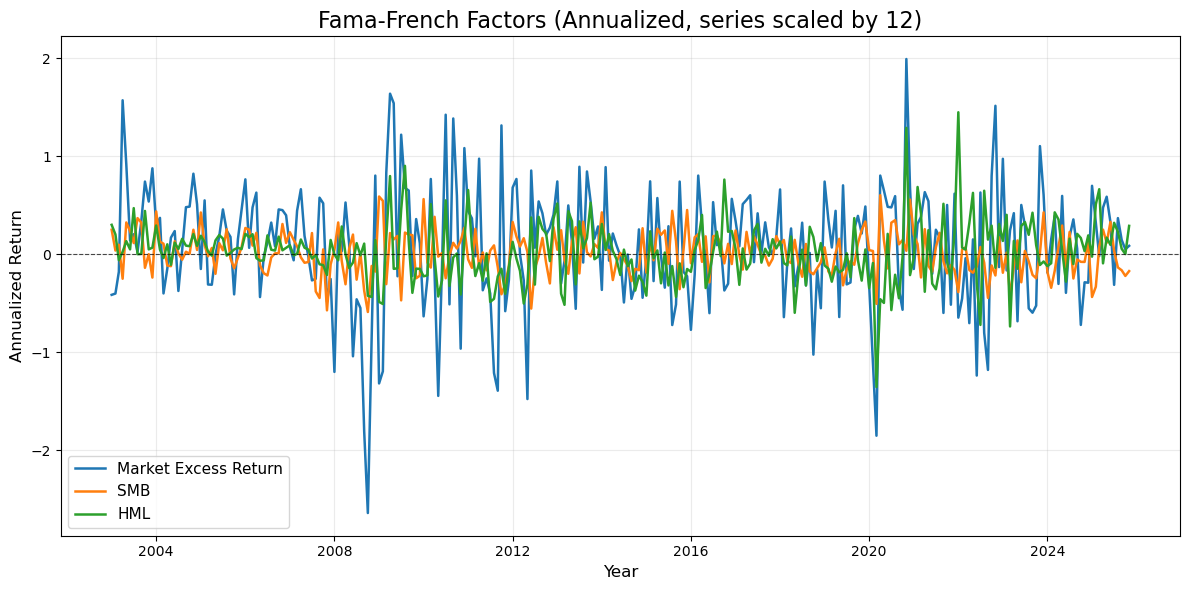

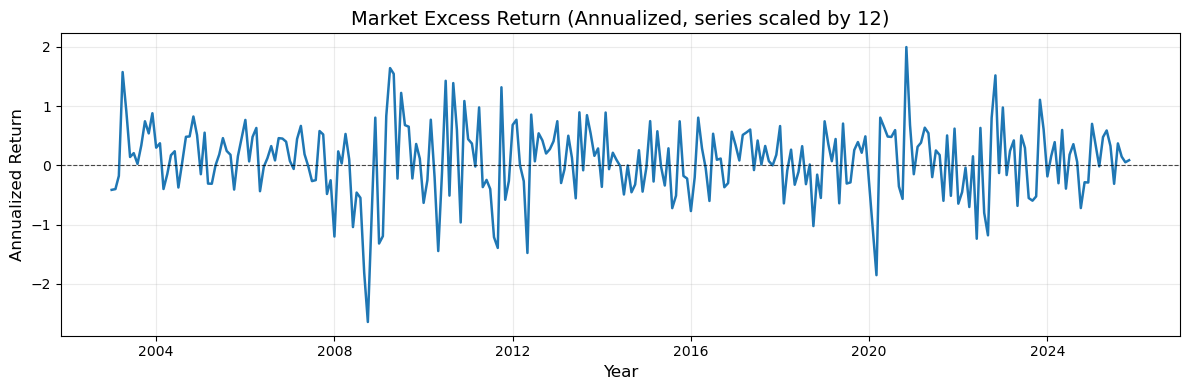

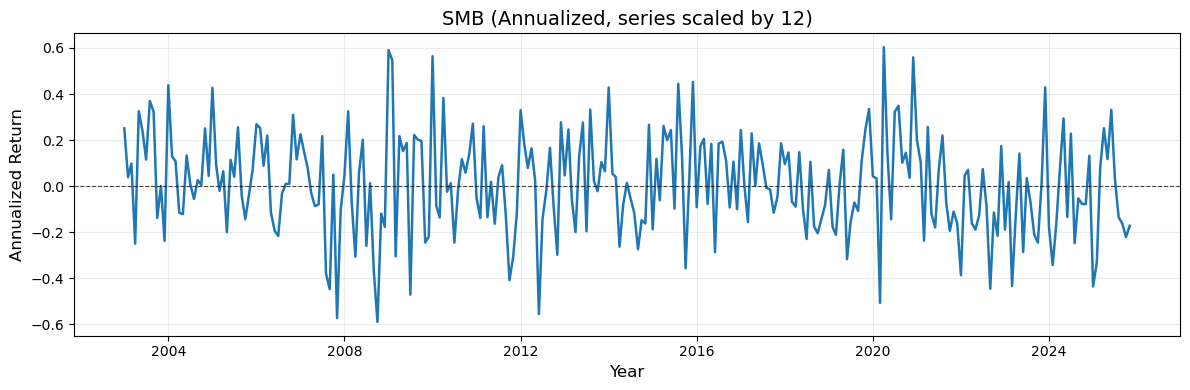

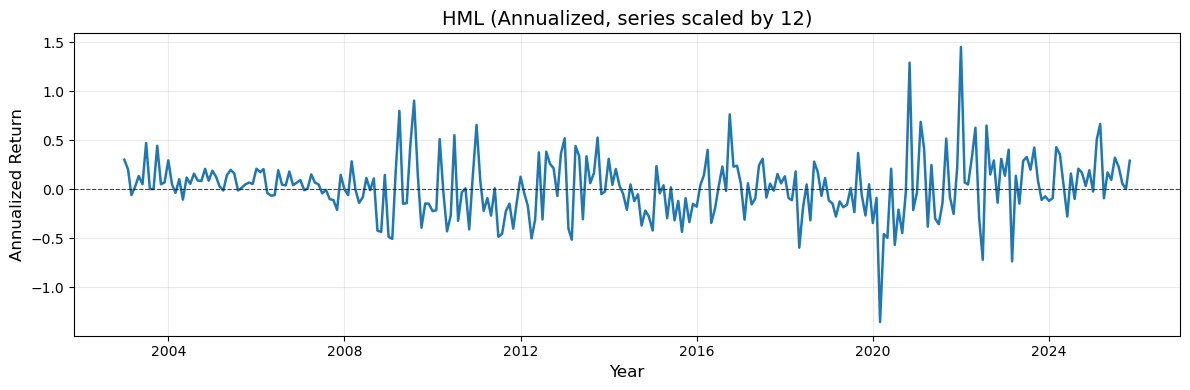

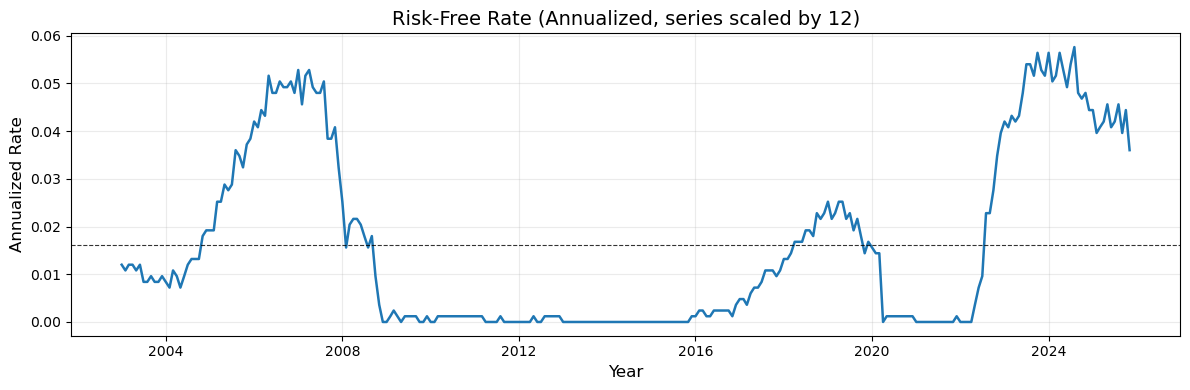

,"Mean (Annual, decimal)","Std Dev (Annual, decimal)"
Rm - Rf,0.0841,0.1790
SMB,0.0087,0.0631
HML,0.0218,0.0887


,"rf_mean (Annual, decimal)"
0,0.0161


,Market Excess,SMB,HML,Risk-Free
Market Excess,0.0320,0.0007,0.0052,0.0000
SMB,0.0007,0.0040,-0.0005,-0.0000
HML,0.0052,-0.0005,0.0079,0.0001
Risk-Free,0.0000,-0.0000,0.0001,0.0000


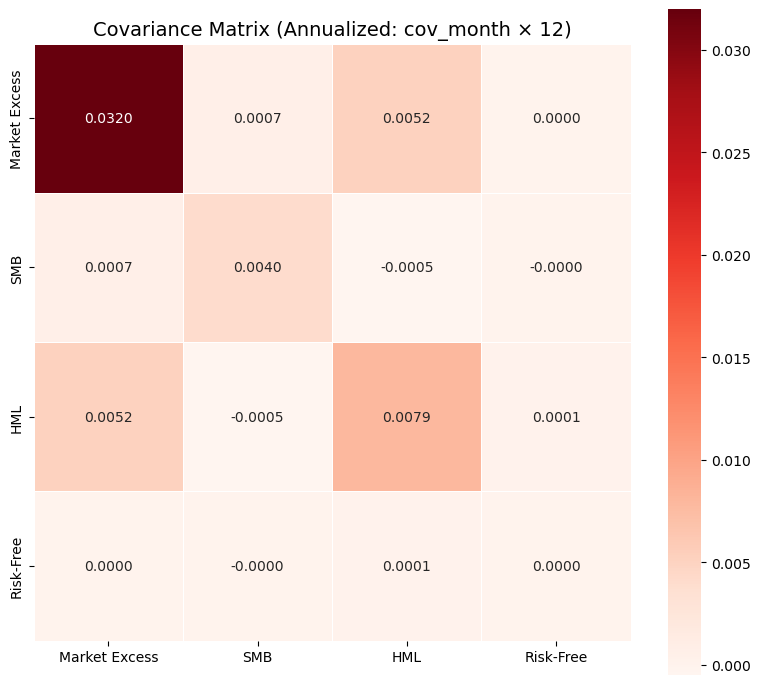

,Market Excess,SMB,HML,Risk-Free
Market Excess,1.0000,0.0576,0.3302,0.0100
SMB,0.0576,1.0000,-0.0812,-0.1392
HML,0.3302,-0.0812,1.0000,0.1140
Risk-Free,0.0100,-0.1392,0.1140,1.0000


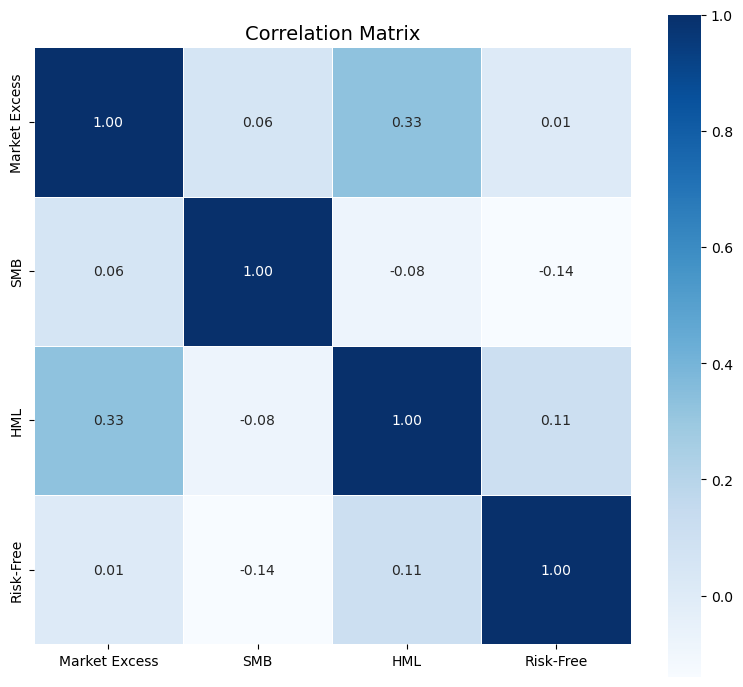

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Copy data ---
factors_q1 = factors.copy()
stocks_q1  = stocks.copy()

# --- Ensure numeric ---
factor_cols = ['rm_rf', 'smb_vw', 'hml_vw', 'rf']
f = factors_q1[factor_cols].apply(pd.to_numeric, errors='coerce')

# --- Build date index (year/month if available) ---
cols_lower = {c.lower(): c for c in factors_q1.columns}
if 'year' in cols_lower and 'month' in cols_lower:
    x_dates = pd.to_datetime(
        dict(
            year=factors_q1[cols_lower['year']].astype(int),
            month=factors_q1[cols_lower['month']].astype(int),
            day=1
        )
    )
else:
    # fallback: use index if already datetime-like
    x_dates = factors_q1.index

# =========================
# 1) PLOTS (Annualized units for visualization)
# =========================
# Following the assignment instruction for "annual units" in plots:
f_plot = f * 12

plt.figure(figsize=(12,6))
plt.plot(x_dates, f_plot['rm_rf'], label='Market Excess Return', linewidth=1.8)
plt.plot(x_dates, f_plot['smb_vw'], label='SMB', linewidth=1.8)
plt.plot(x_dates, f_plot['hml_vw'], label='HML', linewidth=1.8)
plt.axhline(0, color='black', linewidth=0.8, alpha=0.7, linestyle='--')
plt.title("Fama-French Factors (Annualized, series scaled by 12)", fontsize=16)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Annualized Return", fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

for col, ttl in [('rm_rf','Market Excess Return'),
                 ('smb_vw','SMB'),
                 ('hml_vw','HML')]:
    plt.figure(figsize=(12,4))
    plt.plot(x_dates, f_plot[col], linewidth=1.8)
    plt.axhline(0, color='black', linewidth=0.8, alpha=0.7, linestyle='--')
    plt.title(f"{ttl} (Annualized, series scaled by 12)", fontsize=14)
    plt.xlabel("Year", fontsize=12)
    plt.ylabel("Annualized Return", fontsize=12)
    plt.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()

# Risk-free plot (annualized series)
rf_plot = f_plot['rf']
rf_mean_annual = f['rf'].mean() * 12  # annualized mean

plt.figure(figsize=(12,4))
plt.plot(x_dates, rf_plot, linewidth=1.8)
plt.axhline(rf_mean_annual, color='black', linewidth=0.8, alpha=0.8, linestyle='--')
plt.title("Risk-Free Rate (Annualized, series scaled by 12)", fontsize=14)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Annualized Rate", fontsize=12)
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

# =========================
# 2) SUMMARY STATS (Correct annualization of moments)
# =========================
# Annualized mean: 12 * mean_month
# Annualized std : sqrt(12) * std_month
# Annualized cov : 12 * cov_month

mean_ann = f[['rm_rf','smb_vw','hml_vw']].mean() * 12
std_ann  = f[['rm_rf','smb_vw','hml_vw']].std() * np.sqrt(12)

factor_stats = pd.DataFrame({
    "Mean (Annual, decimal)": mean_ann,
    "Std Dev (Annual, decimal)": std_ann
})
factor_stats.index = ["Rm - Rf", "SMB", "HML"]
display(factor_stats.round(4))

display(pd.DataFrame({"rf_mean (Annual, decimal)": [rf_mean_annual]}).round(4))

# =========================
# 3) COVARIANCE + HEATMAP
# =========================
cov_ann = f[['rm_rf','smb_vw','hml_vw','rf']].cov() * 12
cov_ann.index = ['Market Excess', 'SMB', 'HML', 'Risk-Free']
cov_ann.columns = ['Market Excess', 'SMB', 'HML', 'Risk-Free']

# Table view (optional but often nice in report)
display(cov_ann.round(4))

# Heatmap view (covariance)
plt.figure(figsize=(8,7))
sns.heatmap(
    cov_ann.round(4),
    annot=True,
    fmt=".4f",
    cmap="Reds",
    linewidths=0.5,
    linecolor="white",
    square=True,
    cbar=True,
    annot_kws={"size":10}
)
plt.title("Covariance Matrix (Annualized: cov_month × 12)", fontsize=14)
plt.tight_layout()
plt.show()

# =========================
# 4) OPTIONAL: CORRELATION + HEATMAP (more interpretable)
# =========================
corr = f[['rm_rf','smb_vw','hml_vw','rf']].corr()
corr.index = ['Market Excess', 'SMB', 'HML', 'Risk-Free']
corr.columns = ['Market Excess', 'SMB', 'HML', 'Risk-Free']

display(corr.round(4))

plt.figure(figsize=(8,7))
sns.heatmap(
    corr.round(2),
    annot=True,
    fmt=".2f",
    cmap="Blues",
    linewidths=0.5,
    linecolor="white",
    square=True,
    cbar=True,
    annot_kws={"size":10}
)
plt.title("Correlation Matrix", fontsize=14)
plt.tight_layout()
plt.show()

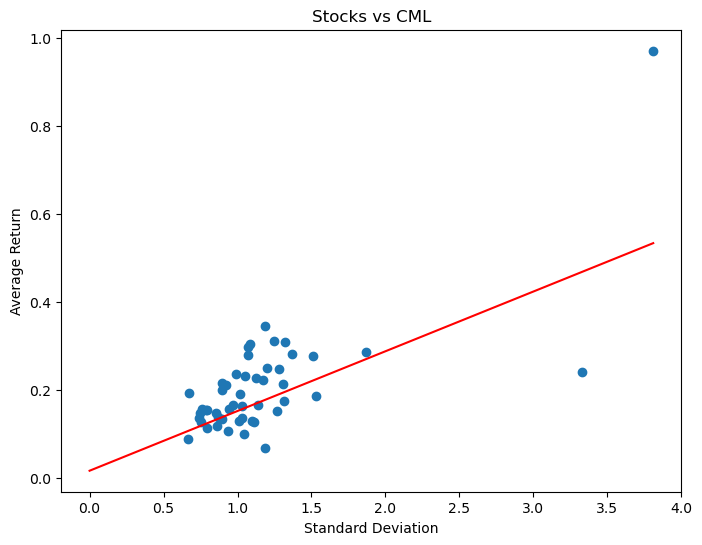

In [7]:
# Medel & STD aktier
stock_means = stocks.iloc[:,3:].mean()
stock_std = stocks.iloc[:,3:].std()

# CML
rf = factors['rf'].mean()
market_mean = factors['rm_rf'].mean() + rf
market_std = factors['rm_rf'].std()

x = np.linspace(0, stock_std.max(), 100)
cml = rf + (market_mean - rf)/market_std * x

# Scatter aktier
plt.figure(figsize=(8,6))
plt.scatter(stock_std, stock_means)
plt.plot(x, cml, color='red')
plt.xlabel("Standard Deviation")
plt.ylabel("Average Return")
plt.title("Stocks vs CML")
plt.show()


3.)

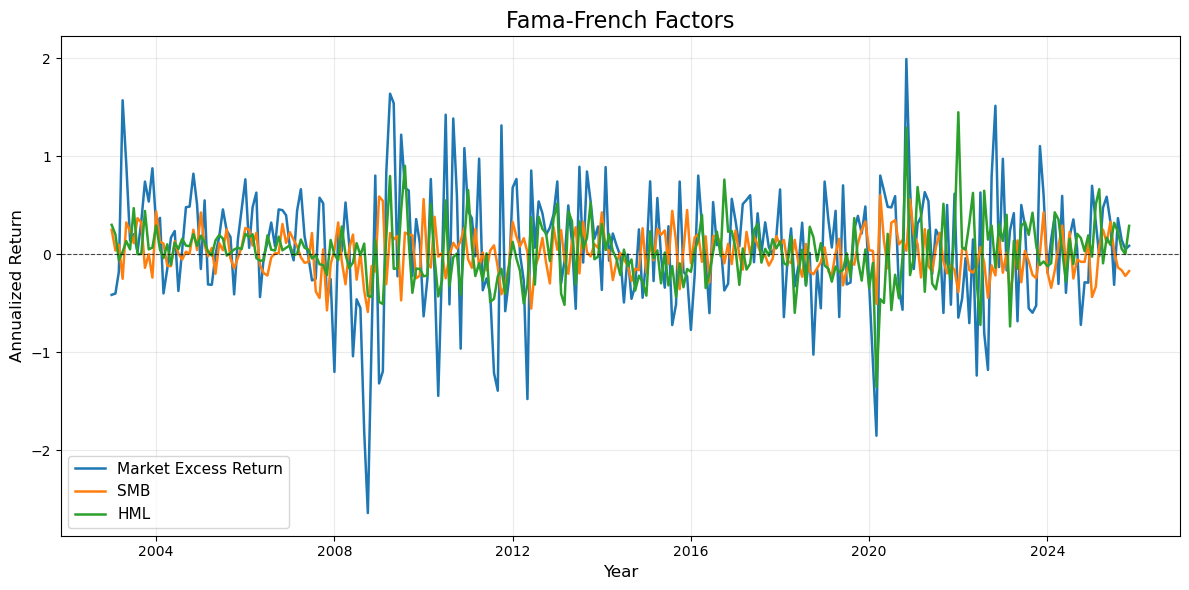

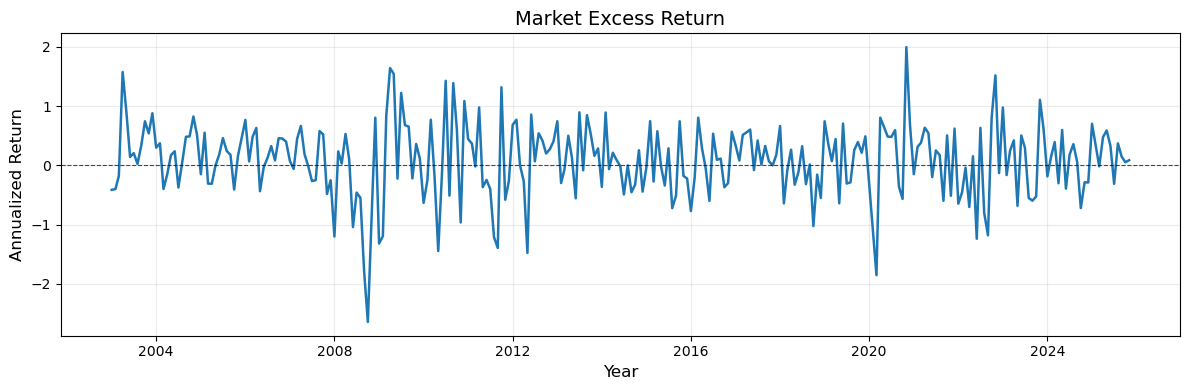

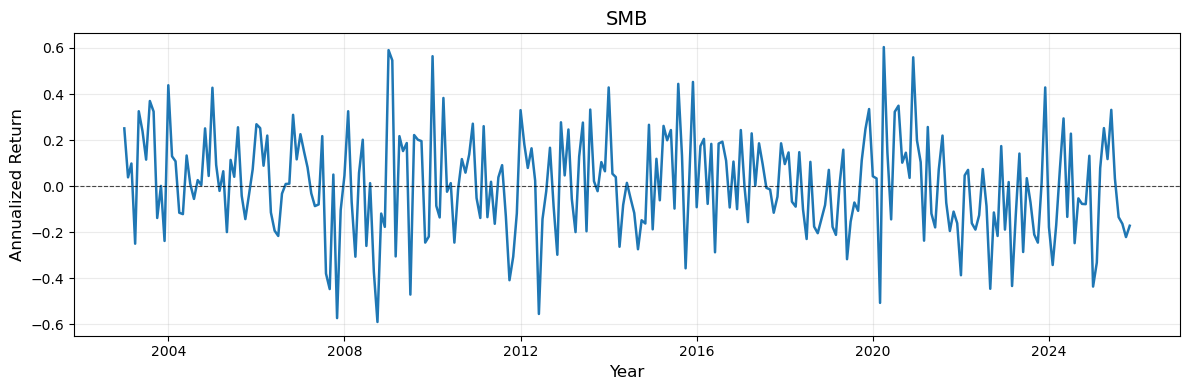

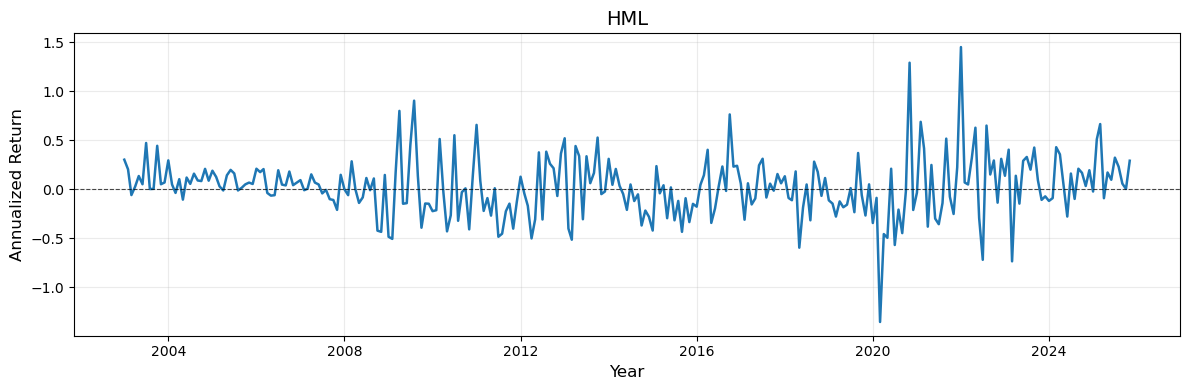

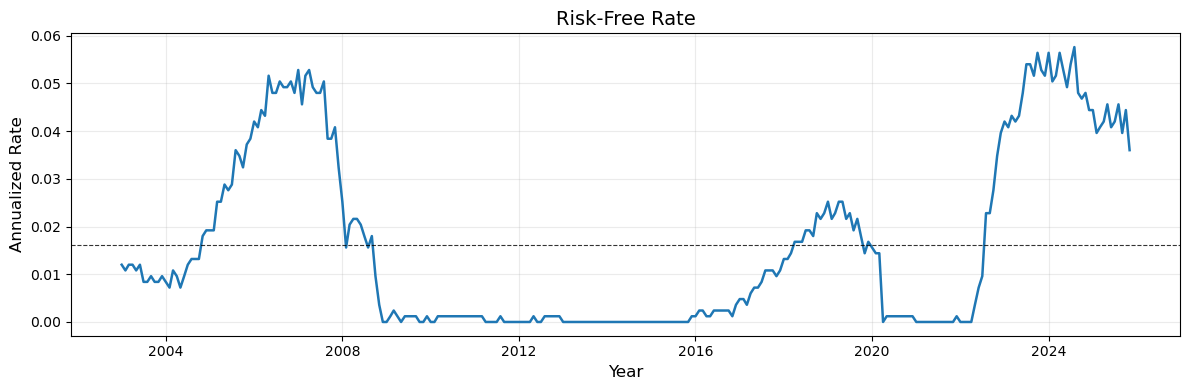

,"Mean (Annual, decimal)","Std Dev (Annual, decimal)"
Rm - Rf,0.0841,0.1790
SMB,0.0087,0.0631
HML,0.0218,0.0887


,"rf_mean (Annual, decimal)"
0,0.0161


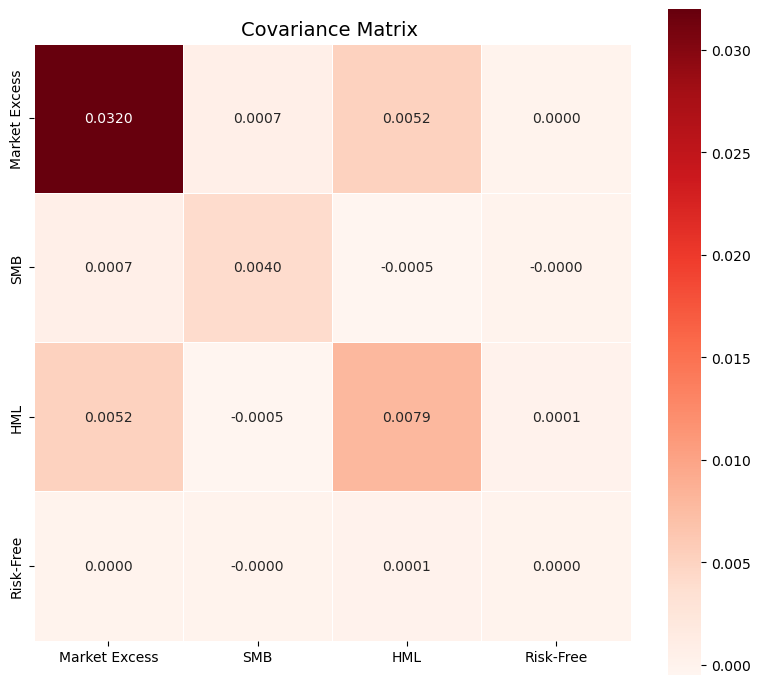

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

factors_q1 = factors.copy()
stocks_q1  = stocks.copy()

factor_cols = ['rm_rf', 'smb_vw', 'hml_vw', 'rf']
f = factors_q1[factor_cols].apply(pd.to_numeric, errors='coerce')

cols_lower = {c.lower(): c for c in factors_q1.columns}
if 'year' in cols_lower and 'month' in cols_lower:
    x_dates = pd.to_datetime(
        dict(
            year=factors_q1[cols_lower['year']].astype(int),
            month=factors_q1[cols_lower['month']].astype(int),
            day=1
        )
    )
else:
    x_dates = factors_q1.index


f_plot = f * 12

plt.figure(figsize=(12,6))
plt.plot(x_dates, f_plot['rm_rf'], label='Market Excess Return', linewidth=1.8)
plt.plot(x_dates, f_plot['smb_vw'], label='SMB', linewidth=1.8)
plt.plot(x_dates, f_plot['hml_vw'], label='HML', linewidth=1.8)
plt.axhline(0, color='black', linewidth=0.8, alpha=0.7, linestyle='--')
plt.title("Fama-French Factors", fontsize=16)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Annualized Return", fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

for col, ttl in [('rm_rf','Market Excess Return'),
                 ('smb_vw','SMB'),
                 ('hml_vw','HML')]:
    plt.figure(figsize=(12,4))
    plt.plot(x_dates, f_plot[col], linewidth=1.8)
    plt.axhline(0, color='black', linewidth=0.8, alpha=0.7, linestyle='--')
    plt.title(f"{ttl}", fontsize=14)
    plt.xlabel("Year", fontsize=12)
    plt.ylabel("Annualized Return", fontsize=12)
    plt.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()

rf_plot = f_plot['rf']
rf_mean_annual = f['rf'].mean() * 12

plt.figure(figsize=(12,4))
plt.plot(x_dates, rf_plot, linewidth=1.8)
plt.axhline(rf_mean_annual, color='black', linewidth=0.8, alpha=0.8, linestyle='--')
plt.title("Risk-Free Rate", fontsize=14)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Annualized Rate", fontsize=12)
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

mean_ann = f[['rm_rf','smb_vw','hml_vw']].mean() * 12
std_ann  = f[['rm_rf','smb_vw','hml_vw']].std() * np.sqrt(12)

factor_stats = pd.DataFrame({
    "Mean (Annual, decimal)": mean_ann,
    "Std Dev (Annual, decimal)": std_ann
})
factor_stats.index = ["Rm - Rf", "SMB", "HML"]
display(factor_stats.round(4))

display(pd.DataFrame({"rf_mean (Annual, decimal)": [rf_mean_annual]}).round(4))

cov_ann = f[['rm_rf','smb_vw','hml_vw','rf']].cov() * 12
cov_ann.index = ['Market Excess', 'SMB', 'HML', 'Risk-Free']
cov_ann.columns = ['Market Excess', 'SMB', 'HML', 'Risk-Free']

plt.figure(figsize=(8,7))
sns.heatmap(
    cov_ann.round(4),
    annot=True,
    fmt=".4f",
    cmap="Reds",
    linewidths=0.5,
    linecolor="white",
    square=True,
    cbar=True,
    annot_kws={"size":10}
)
plt.title("Covariance Matrix ", fontsize=14)
plt.tight_layout()
plt.show()

In [8]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

R  = stocks.iloc[:,3:]                  # aktier (annualiserade obs)
rf = factors["rf"]
m  = factors["rm_rf"]
s  = factors["smb_vw"]
h  = factors["hml_vw"]

# samma längd
n = min(len(R), len(factors))
R, rf, m, s, h = R.iloc[:n], rf.iloc[:n], m.iloc[:n], s.iloc[:n], h.iloc[:n]

mu_rf, mu_m, mu_s, mu_h = rf.mean(), m.mean(), s.mean(), h.mean()

rows = []
for col in R.columns:
    y = R[col] - rf

    capm = sm.OLS(y, sm.add_constant(m), missing="drop").fit()
    b_m  = capm.params["rm_rf"]

    ff3 = sm.OLS(y, sm.add_constant(pd.DataFrame({"rm_rf":m, "smb_vw":s, "hml_vw":h})),
                 missing="drop").fit()
    b_m3, b_s3, b_h3 = ff3.params["rm_rf"], ff3.params["smb_vw"], ff3.params["hml_vw"]

    ER_capm = mu_rf + b_m  * mu_m
    ER_ff3  = mu_rf + b_m3 * mu_m + b_s3 * mu_s + b_h3 * mu_h

    rows.append([col, b_m, b_m3, b_s3, b_h3, ER_capm, ER_ff3])

res3 = pd.DataFrame(rows, columns=[
    "Stock","beta_CAPM","betaM_FF3","betaSMB","betaHML","E[R]_CAPM","E[R]_FF3"
]).set_index("Stock")

res3["Diff_FF3_minus_CAPM_pp"] = 100*(res3["E[R]_FF3"] - res3["E[R]_CAPM"])
print(res3.sort_values("Diff_FF3_minus_CAPM_pp", ascending=False).head(15))


                             beta_CAPM  betaM_FF3   betaSMB   betaHML  \
Stock                                                                   
Copperstone Resources AB B    0.350808   0.388900  2.145185 -0.412113   
Bergman & Beving AB B         0.954404   0.902399  1.590383  0.107576   
Avanza Bank Holding AB        0.794548   0.786632  1.660314 -0.168237   
NOTE AB                       0.948141   0.947666  1.312779 -0.191580   
RaySearch Laboratories AB B   0.927772   0.954787  1.341959 -0.338111   
Orron Energy AB               0.948298   0.966140  1.228499 -0.267852   
SEB AB A                      0.941340   0.825600  0.037032  0.695341   
ITAB Shop Concept AB          0.808055   0.872884  1.544753 -0.614950   
Swedbank AB A                 1.043848   0.921244 -0.141603  0.760125   
Bahnhof AB B                  0.215760   0.294106  1.231620 -0.566909   
Ework Group AB                0.653512   0.685954  0.898420 -0.272769   
Saab AB B                     0.684451   0.635095  

4.)

Mean/Std (annualized obs) for size portfolios:
               mean       std
Portfolio                    
S1         0.195200  0.683336
S2         0.203507  0.786934
S3         0.151725  0.598940
S4         0.139637  0.604384
S5         0.113895  0.542318

CAPM alpha per portfolio (decimal/yr):
              alpha  t(alpha)  p(alpha)      beta
Portfolio                                        
S1         0.104308  2.478635  0.014615  0.910114
S2         0.112298  2.174189  0.031704  0.991150
S3         0.072619  1.953327  0.053168  0.796401
S4         0.056353  1.475959  0.142641  0.783566
S5         0.037932  1.121683  0.264294  0.711980

CAPM alpha per portfolio (%/yr):
Portfolio
S1    10.430839
S2    11.229788
S3     7.261903
S4     5.635345
S5     3.793151
Name: alpha, dtype: float64


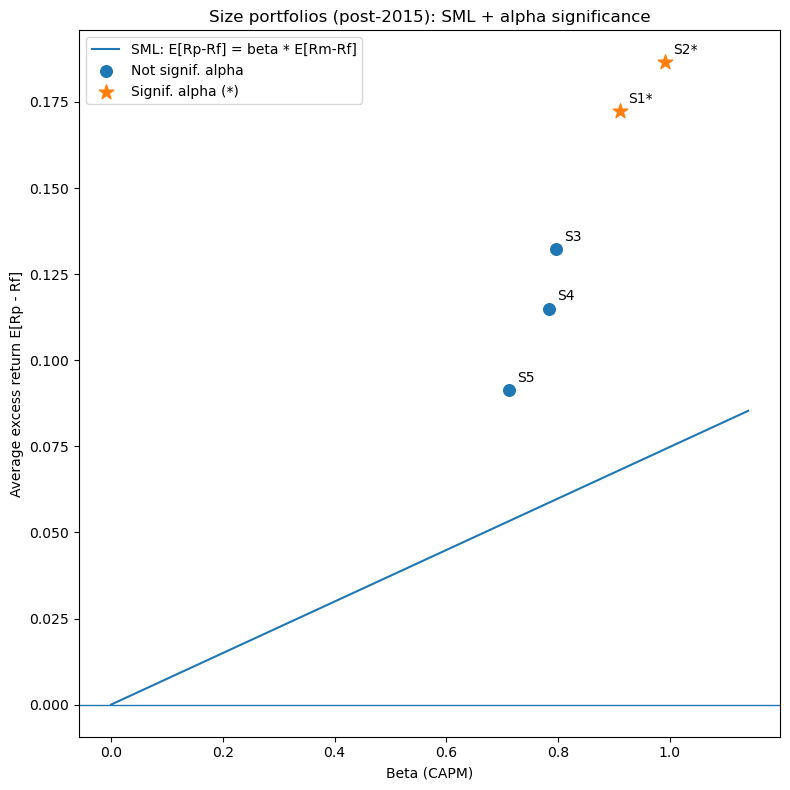

           mean_excess      beta     alpha   p_alpha
Portfolio                                           
S1            0.172425  0.910114  0.104308  0.014615
S2            0.186479  0.991150  0.112298  0.031704
S3            0.132225  0.796401  0.072619  0.053168
S4            0.114998  0.783566  0.056353  0.142641
S5            0.091219  0.711980  0.037932  0.264294


In [39]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

# --- load ---
rets = pd.read_excel("project Stocks_2026.xlsx", sheet_name="return")
mcap = pd.read_excel("project Stocks_2026.xlsx", sheet_name="Market cap")
f    = pd.read_excel("project Factors_2026.xlsx")  # factors-sheet

# --- annualize obs (monthly * 12) ---
f[["rf","rm_rf","smb_vw","hml_vw"]] = f[["rf","rm_rf","smb_vw","hml_vw"]] * 12
rets.iloc[:,3:] = rets.iloc[:,3:] * 12  # returns only (NOT caps)

# --- align keys ---
f = f.rename(columns={"year":"Year","month":"Month"})
fac = f[["Year","Month","rf","rm_rf"]].copy()

# --- post-2015 (from 2016) ---
rets = rets[rets["Year"] >= 2016].copy()
mcap = mcap[mcap["Year"] >= 2016].copy()

stock_cols = rets.columns[3:]

# --- build 5 size-sorted EW portfolios each year using cap at beginning of year ---
rows = []
for yr in sorted(rets["Year"].unique()):
    R_y = rets[rets["Year"] == yr]
    C_y = mcap[mcap["Year"] == yr]
    if R_y.empty or C_y.empty:
        continue

    # cap at start of year: January if exists, else first available month
    C_jan = C_y[C_y["Month"] == 1]
    cap0 = (C_jan.iloc[0] if not C_jan.empty else C_y.iloc[0])[stock_cols].dropna()

    # 5 groups (1=small ... 5=large), robust vs ties
    ranks = cap0.rank(method="first")
    g = pd.qcut(ranks, 5, labels=[1,2,3,4,5])

    for _, r in R_y.iterrows():
        for k in [1,2,3,4,5]:
            members = g.index[g == k]
            rows.append({
                "Year": r["Year"], "Month": r["Month"],
                "Portfolio": f"S{k}",
                "ret": r[members].mean(skipna=True)
            })

ports = pd.DataFrame(rows)

# --- report mean/std ---
stats4 = ports.groupby("Portfolio")["ret"].agg(["mean","std"])
print("Mean/Std (annualized obs) for size portfolios:")
print(stats4)

# --- CAPM alpha: (Rp - rf) = alpha + beta*(rm-rf) + eps ---
ports = ports.merge(fac, on=["Year","Month"], how="inner")
ports["excess"] = ports["ret"] - ports["rf"]

alpha_rows = []
for p in sorted(ports["Portfolio"].unique()):
    dfp = ports[ports["Portfolio"] == p].dropna(subset=["excess","rm_rf"])
    fit = sm.OLS(dfp["excess"], sm.add_constant(dfp["rm_rf"])).fit()
    alpha_rows.append([p, fit.params["const"], fit.tvalues["const"], fit.pvalues["const"], fit.params["rm_rf"]])

alpha4 = pd.DataFrame(alpha_rows, columns=["Portfolio","alpha","t(alpha)","p(alpha)","beta"]).set_index("Portfolio")
print("\nCAPM alpha per portfolio (decimal/yr):")
print(alpha4)

print("\nCAPM alpha per portfolio (%/yr):")
print(100*alpha4["alpha"])

if figurer==True:
    reg_rows = []
    for p, dfp in ports.groupby("Portfolio"):
        dfp = dfp.dropna(subset=["excess", "rm_rf"])
        fit = sm.OLS(dfp["excess"], sm.add_constant(dfp["rm_rf"])).fit()
        reg_rows.append({
            "Portfolio": p,
            "mean_excess": dfp["excess"].mean(),
            "beta": fit.params["rm_rf"],
            "alpha": fit.params["const"],
            "p_alpha": fit.pvalues["const"]
        })

    reg = pd.DataFrame(reg_rows).set_index("Portfolio").loc[["S1","S2","S3","S4","S5"]]

    # SML-linje (post-2015 sample)
    mu_mkt = ports["rm_rf"].mean()  # E[Rm-Rf]
    x = np.linspace(0, reg["beta"].max()*1.15, 100)
    sml = mu_mkt * x

    # Plot
    plt.figure(figsize=(8,8))
    plt.plot(x, sml, label="SML: E[Rp-Rf] = beta * E[Rm-Rf]")

    sig = reg["p_alpha"] < 0.05
    plt.scatter(reg.loc[~sig, "beta"], reg.loc[~sig, "mean_excess"], label="Not signif. alpha", s=70)
    plt.scatter(reg.loc[sig, "beta"], reg.loc[sig, "mean_excess"], label="Signif. alpha (*)", s=120, marker="*")

    # Annotera med S1..S5 (+ * om signifikant)
    for idx, row in reg.iterrows():
        star = "*" if row["p_alpha"] < 0.05 else ""
        plt.annotate(f"{idx}{star}", (row["beta"], row["mean_excess"]),
                    textcoords="offset points", xytext=(6,6))

    plt.axhline(0, linewidth=1)
    plt.xlabel("Beta (CAPM)")
    plt.ylabel("Average excess return E[Rp - Rf]")
    plt.title("Size portfolios (post-2015): SML + alpha significance")
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(reg)



5.)

In [40]:
import pandas as pd
import statsmodels.api as sm

# --- Load ---
fund_net   = pd.read_excel("project Funds_2026.xlsx", sheet_name="Net")
fund_gross = pd.read_excel("project Funds_2026.xlsx", sheet_name="Gross")
info       = pd.read_excel("project Funds_2026.xlsx", sheet_name="Info")
f          = pd.read_excel("project Factors_2026.xlsx")

# --- Annualize obs (monthly * 12) ---
f[["rf","rm_rf","smb_vw","hml_vw"]] *= 12
fund_net.iloc[:,3:]   *= 12
fund_gross.iloc[:,3:] *= 12

# --- Align keys ---
f = f.rename(columns={"year":"Year","month":"Month"})
fac = f[["Year","Month","rf","rm_rf"]]

net   = fund_net.merge(fac, on=["Year","Month"], how="inner")
gross = fund_gross.merge(fac, on=["Year","Month"], how="inner")

fund_cols = fund_net.columns[3:]

def capm_alpha_only(df):
    alphas = {}
    for c in fund_cols:
        y = df[c] - df["rf"]
        X = sm.add_constant(df["rm_rf"])
        fit = sm.OLS(y, X, missing="drop").fit()
        alphas[c] = fit.params["const"]
    return pd.Series(alphas)

# --- Net & gross alphas ---
alpha_net   = capm_alpha_only(net).rename("net_alpha")
alpha_gross = capm_alpha_only(gross).rename("gross_alpha")

res5 = pd.concat([alpha_net, alpha_gross], axis=1)
res5["gap_gross_minus_net"] = res5["gross_alpha"] - res5["net_alpha"]  # decimal/yr

# --- Add fund type (active/passive) if available ---
if "Fund name" in info.columns and "fund type" in info.columns:
    res5 = res5.join(info.set_index("Fund name")[["fund type"]], how="left")

# 1) Output: net alphas for each fund
print("Net CAPM alpha per fund (decimal/yr):")
print(res5[["net_alpha"]].sort_values("net_alpha", ascending=False))

# 2) Output: compare net vs gross gap by fund type
if "fund type" in res5.columns:
    summary = res5.groupby("fund type")[["net_alpha","gross_alpha","gap_gross_minus_net"]].mean()
    print("\nAverage net/gross alpha and gap by fund type (decimal/yr):")
    print(summary)


Net CAPM alpha per fund (decimal/yr):
                                        net_alpha
Swedbank Robur Exportfond A              0.073069
Aktiespararna Topp Sverige Hållbar A     0.063634
Swedbank Robur Småbolagsfond Sverige A   0.046981
Öhman Sweden Micro Cap A                 0.042233
SEB Sweden Equity C                      0.037303
Storebrand Sverige A SEK                 0.029791
Swedbank Robur Sverige A                 0.021438
Enter Sverige Hållbar Tillväxt A         0.020193
AMF Aktiefond Sverige                    0.014829
AMF Aktiefond Småbolag                   0.011179

Average net/gross alpha and gap by fund type (decimal/yr):
                               net_alpha  gross_alpha  gap_gross_minus_net
fund type                                                                 
actively managed equity fund    0.033403     0.041523             0.008120
index-based equity fund         0.029791     0.031409             0.001618
passively managed equity fund   0.063634     0.06976

6.)

Estimated (alpha, beta, sigma^2_eps):
                        alpha      beta  sig2_eps
Volvo AB A           0.086606  1.017360  0.633278
Assa Abloy AB B      0.089246  0.585265  0.501144
Handelsbanken AB A   0.066690  0.606515  0.405457
Industrivarden AB A  0.062687  0.857950  0.333920

Active portfolio weights (within A), sum=1:
Volvo AB A             0.205017
Assa Abloy AB B        0.266972
Handelsbanken AB A     0.246578
Industrivarden AB A    0.281433
dtype: float64

Active portfolio stats:
alpha_A = 0.075668405847599
beta_A  = 0.7558342154814564
sig2_eps_A = 0.11343660653829761


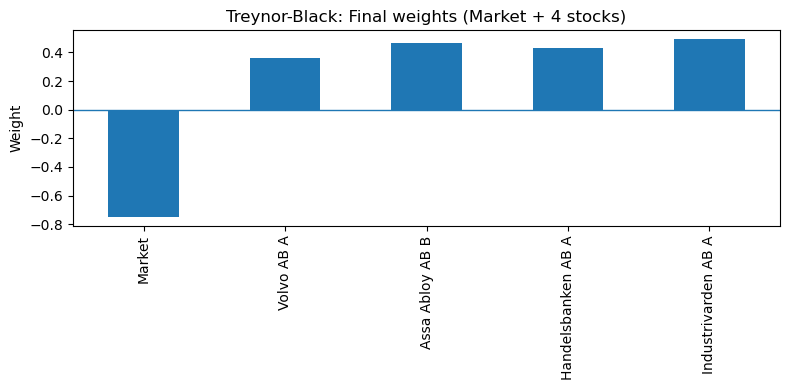

In [35]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

# --- names ---
names = ["Volvo AB A", "Assa Abloy AB B", "Handelsbanken AB A", "Industrivarden AB A"]

# --- load ---
rets = pd.read_excel("project Stocks_2026.xlsx", sheet_name="return")
f    = pd.read_excel("project Factors_2026.xlsx")

# --- annualize obs ---
f[["rf","rm_rf","smb_vw","hml_vw"]] = f[["rf","rm_rf","smb_vw","hml_vw"]] * 12
rets.iloc[:,3:] = rets.iloc[:,3:] * 12

# --- align by Year/Month ---
f = f.rename(columns={"year":"Year","month":"Month"})
data = rets.merge(f[["Year","Month","rf","rm_rf"]], on=["Year","Month"], how="inner")

Rm = data["rm_rf"]                 # market excess
mu_Rm  = Rm.mean()
var_Rm = Rm.var()

# --- Step 1: estimate alpha_i, beta_i, sigma^2_eps_i from CAPM regression ---
alpha = {}
beta  = {}
sig2e = {}

for s in names:
    Ri = data[s] - data["rf"]      # excess return of stock i
    fit = sm.OLS(Ri, sm.add_constant(Rm), missing="drop").fit()
    alpha[s] = fit.params["const"]
    beta[s]  = fit.params["rm_rf"]
    sig2e[s] = np.var(fit.resid, ddof=1)

alpha = pd.Series(alpha)
beta  = pd.Series(beta)
sig2e = pd.Series(sig2e)

print("Estimated (alpha, beta, sigma^2_eps):")
print(pd.DataFrame({"alpha":alpha, "beta":beta, "sig2_eps":sig2e}))

# --- Step 2: Active-portfolio weights: w_i ∝ alpha_i / sigma^2_eps_i ---
score = alpha / sig2e
w_i = score / score.sum()          # sums to 1 (can be negative for negative alpha)
print("\nActive portfolio weights (within A), sum=1:")
print(w_i)

# --- Step 3: Active-portfolio stats ---
alpha_A = np.sum(w_i * alpha)
beta_A  = np.sum(w_i * beta)
sig2e_A = np.sum((w_i**2) * sig2e)

print("\nActive portfolio stats:")
print("alpha_A =", alpha_A)
print("beta_A  =", beta_A)
print("sig2_eps_A =", sig2e_A)

# --- Step 4: mix Active + Passive (index), Treynor–Black ---
# wA0 = (alpha_A/sig2e_A) / (E[Rm]/sig2_m)
wA0 = (alpha_A / sig2e_A) / (mu_Rm / var_Rm)

# beta-correction: wA* = wA0 / (1 + (1 - beta_A) wA0)
wA_star = wA0 / (1 + (1 - beta_A) * wA0)

wM_star = 1 - wA_star
w_final = pd.Series({"Market": wM_star})
w_final = pd.concat([w_final, wA_star * w_i])

import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
w_final.plot(kind="bar")
plt.axhline(0, linewidth=1)
plt.title("Treynor-Black: Final weights (Market + 4 stocks)")
plt.ylabel("Weight")
plt.tight_layout()
plt.show()
